**Text Analysis of books using word cloud:**

In [161]:
# 1. Using requests to access the contents online, create a function load_texts().This function should recive a list of urls, load them, clean non-words using regular expressions and append the cleaned text to the corpus that will be returned.

import requests
import re

def load_texts(urls):
    corpus = []

    for url in urls:
        response = requests.get(url)
        response.raise_for_status()

        text = response.text

        # remove non-word characters and digits
        text = re.sub(r'[^A-Za-z\s]', ' ', text)

        # remove extra spaces
        text = re.sub(r'\s+', ' ', text)

        # lowercase
        text = text.lower().strip()

        corpus.append(text)

    return corpus

In [162]:
urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
]

corpus = load_texts(urls)

print(len(corpus))
print(corpus[0][:500])

3
the project gutenberg ebook of alice s adventures in wonderland this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions whatsoever you may copy it give it away or re use it under the terms of the project gutenberg license included with this ebook or online at www gutenberg org if you are not located in the united states you will have to check the laws of the country where you are located before using this eboo


In [163]:
# 2. Print the first 200 characteres of each text. Are there parts of the text that are not relevant to the analysis? If so, you need to remove them hint: You can use slicing to start and stop the text where you need (ignoring autoral credits in the begining and end) looking for the following phrases:

for i, text in enumerate(corpus):
    print(f"\n--- Text {i+1} ---")
    print(text[:200])




--- Text 1 ---
the project gutenberg ebook of alice s adventures in wonderland this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restri

--- Text 2 ---
the project gutenberg ebook of through the looking glass this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions 

--- Text 3 ---
the project gutenberg ebook of a tangled tale this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions whatsoever 


In [164]:
cleaned_corpus = []

for text in corpus:
    start = text.find("start")
    end = text.find("end")

    if start != -1 and end != -1:
        text = text[start:end]

    cleaned_corpus.append(text)

In [165]:
for i, text in enumerate(cleaned_corpus):
    print(f"\n--- Cleaned Text {i+1} ---")
    print(text[:200])


--- Cleaned Text 1 ---
start of the project gutenberg ebook alice s adventures in wonderland illustration alice s adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbit h

--- Cleaned Text 2 ---
start of the project gutenberg ebook through the looking glass illustration through the looking glass and what alice found there by lewis carroll the millennium fulcrum edition dramatis person as arra

--- Cleaned Text 3 ---
start of the project gutenberg ebook a tangled tale produced by chris curnow carla foust lindy walsh and the online distributed proofreading team at https www pgdp net music transcribed by linda canto


In [166]:
# 3. Tokenize the text and print the first 150 tokens of each book

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

tokenized_corpus = []

for text in cleaned_corpus:
    tokens = word_tokenize(text)
    tokenized_corpus.append(tokens)

for i, tokens in enumerate(tokenized_corpus):
    print(f"\n--- Book {i+1} ---")
    print(tokens[:150])


--- Book 1 ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventures', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 's']

--- Book 2 ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'through', 'the', 'looking', 'glass', 'illustration', 'through', 'the', 'looking', 'glass', 'and', 'what', 'alice', 'found', 'there', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'as', 'arranged', 'before', 'commencement', 'of', 'game', 'white', 'red', 'pieces', 'pawns', 'pawns', 'pieces', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oys

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [167]:
# 4. Remove stopwords using NLTK. Check that they were removed using count() and looking for some of the stop words like: ‘i’, ‘me’, ‘my’, ‘myself’, ‘we’, ‘our’, ‘ours’, ‘ourselves’, etc.

from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

filtered_corpus = []

for tokens in tokenized_corpus:
    filtered = [word for word in tokens if word.lower() not in stop_words]
    filtered_corpus.append(filtered)

check_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']

for i, tokens in enumerate(filtered_corpus):
    print(f"\n--- Book {i+1} ---")
    for w in check_words:
        print(f"{w}: {tokens.count(w)}")


--- Book 1 ---
i: 0
me: 0
my: 0
myself: 0
we: 0
our: 0
ours: 0
ourselves: 0

--- Book 2 ---
i: 0
me: 0
my: 0
myself: 0
we: 0
our: 0
ours: 0
ourselves: 0

--- Book 3 ---
i: 0
me: 0
my: 0
myself: 0
we: 0
our: 0
ours: 0
ourselves: 0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [168]:
# 5. Using PorterStemmer(), print the first 50 stemmed tokens

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed_corpus = []

for tokens in filtered_corpus:
    stemmed = [stemmer.stem(word) for word in tokens]
    stemmed_corpus.append(stemmed)

for i, tokens in enumerate(stemmed_corpus):
    print(f"\n--- Book {i+1} ---")
    print(tokens[:50])


--- Book 1 ---
['start', 'project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit']

--- Book 2 ---
['start', 'project', 'gutenberg', 'ebook', 'look', 'glass', 'illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king', 'fawn']

--- Book 3 ---
['start', 'project', 'gutenberg', 'ebook', 'tangl', 'tale', 'produc', 'chri', 'curnow', 'carla', 'foust', 'lindi', 'walsh', 'onlin', 'distribut', 'proofread', 'team', '

In [169]:
# 6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens. Hint: in spaCy the lemmatized token can be accessed as attribute.

import spacy

# если модель не установлена
!python -m spacy download en_core_web_sm

nlp = spacy.load("en_core_web_sm")

lemmatized_corpus = []

for text in cleaned_corpus:
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    lemmatized_corpus.append(lemmas)

for i, tokens in enumerate(lemmatized_corpus):
    print(f"\n--- Book {i+1} ---")
    print(tokens[:50])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

--- Book 1 ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventure', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventure', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'I', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit']

--- Book 2 ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'through', 'the', 'look', 'glass', 'illustration',

**7. Analyse the difference between the stemmed and lemmatized tokens. What is different and why?**

Stemming produces truncated and sometimes non-real word forms because it removes suffixes using simple rules without considering context.

Lemmatization, on the other hand, returns meaningful base forms of words by using linguistic knowledge such as vocabulary and part-of-speech tagging.

Lemmatized tokens are more accurate and interpretable, while stemmed tokens are faster but less precise.

In [170]:
# 8. Using NLTK, identify POS tags od each text

import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

pos_tagged_corpus = []

for tokens in tokenized_corpus:
    pos_tags = nltk.pos_tag(tokens)
    pos_tagged_corpus.append(pos_tags)

for i, tagged in enumerate(pos_tagged_corpus):
    print(f"\n--- Book {i+1} ---")
    print(tagged[:50])


--- Book 1 ---
[('start', 'NN'), ('of', 'IN'), ('the', 'DT'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('alice', 'NN'), ('s', 'NN'), ('adventures', 'NNS'), ('in', 'IN'), ('wonderland', 'NN'), ('illustration', 'NN'), ('alice', 'NN'), ('s', 'NN'), ('adventures', 'NNS'), ('in', 'IN'), ('wonderland', 'NN'), ('by', 'IN'), ('lewis', 'JJ'), ('carroll', 'NN'), ('the', 'DT'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('contents', 'NNS'), ('chapter', 'NN'), ('i', 'VBP'), ('down', 'RP'), ('the', 'DT'), ('rabbit', 'NN'), ('hole', 'JJ'), ('chapter', 'NN'), ('ii', 'VBP'), ('the', 'DT'), ('pool', 'NN'), ('of', 'IN'), ('tears', 'NNS'), ('chapter', 'NN'), ('iii', 'VBP'), ('a', 'DT'), ('caucus', 'NN'), ('race', 'NN'), ('and', 'CC'), ('a', 'DT'), ('long', 'JJ'), ('tale', 'NN'), ('chapter', 'NN'), ('iv', 'VBP'), ('the', 'DT'), ('rabbit', 'NN')]

--- Book 2 ---
[('start', 'NN'), ('of', 'IN'), ('the', 'DT'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('throug

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [171]:
# 9. Using NLTK identify all the entities of each text
import requests
import re

def load_raw_texts(urls):
    raw_corpus = []

    for url in urls:
        response = requests.get(url)
        response.raise_for_status()

        text = response.text

        start = text.find("START")
        end = text.find("END")

        if start != -1 and end != -1:
            text = text[start:end]

        raw_corpus.append(text)

    return raw_corpus

raw_corpus = load_raw_texts(urls)

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

from nltk.tokenize import word_tokenize
from nltk import pos_tag, ne_chunk

entities_corpus = []

for text in raw_corpus:
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    tree = ne_chunk(pos_tags)
    entities_corpus.append(tree)

for i, tree in enumerate(entities_corpus):
    print(f"\n--- Book {i+1} Entities ---")

    count = 0

    for subtree in tree:
        if hasattr(subtree, 'label'):
            entity_name = " ".join(token for token, pos in subtree)
            entity_label = subtree.label()
            print(entity_name, "-", entity_label)

            count += 1
            if count == 10:
                break

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Pa


--- Book 1 Entities ---
THE - ORGANIZATION
PROJECT - ORGANIZATION
ADVENTURES - ORGANIZATION
Wonderland - GPE
Lewis Carroll THE - PERSON
MILLENNIUM - ORGANIZATION
Pool - ORGANIZATION
Tears - PERSON
Long Tale - ORGANIZATION
Rabbit Sends - ORGANIZATION

--- Book 2 Entities ---
THE - ORGANIZATION
PROJECT - ORGANIZATION
THE - ORGANIZATION
THE - ORGANIZATION
Alice - PERSON
Lewis Carroll - PERSON
Millennium Fulcrum - FACILITY
DRAMATIS - ORGANIZATION
_As - ORGANIZATION
WHITE - ORGANIZATION

--- Book 3 Entities ---
THE - ORGANIZATION
PROJECT - ORGANIZATION
TANGLED - ORGANIZATION
Chris Curnow - PERSON
Carla Foust - PERSON
Lindy Walsh - PERSON
Online Distributed - ORGANIZATION
Music - PERSON
Linda Cantoni - PERSON
TANGLED - ORGANIZATION


**Analysing the text:**

In [172]:
import requests

url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"
response = requests.get(url)

text = response.text

print(text[:1000])

﻿The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Alice's Adventures in Wonderland

Author: Lewis Carroll


        
Release date: June 27, 2008 [eBook #11]
                Most recently updated: June 26, 2025

Language: English

Other information and formats: www.gutenberg.org/ebooks/11

Credits: Arthur DiBianca and David Widger


*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILL


In [173]:
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

cleaned_reviews = [preprocess_text(text) for text in raw_reviews]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [174]:
print(cleaned_reviews)

['alice beginning get tired sitting sister bank rabbithole went straight like tunnel way']


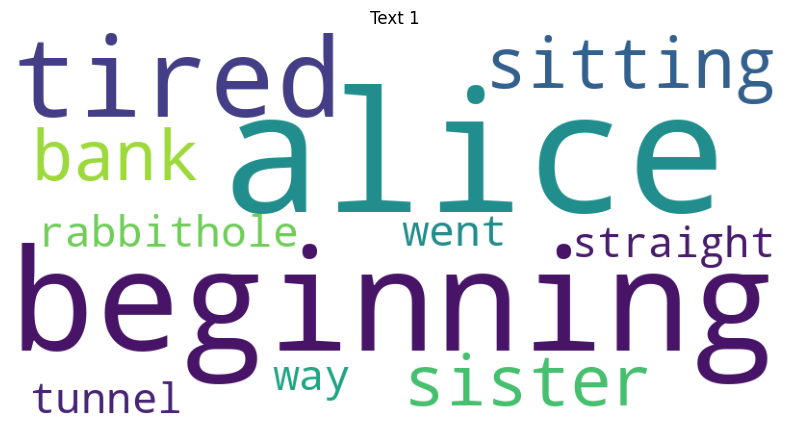

In [175]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texts = cleaned_reviews

for i, text in enumerate(texts):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title(f"Text {i+1}")
    plt.show()

In [176]:
# 2. Use BoW method to check the five most frequent words in all the books

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# используем очищенный текст
texts_for_bow = cleaned_reviews

vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(texts_for_bow)

words = vectorizer.get_feature_names_out()
word_counts = bow_matrix.toarray().sum(axis=0)

freq_df = pd.DataFrame({
    "word": words,
    "frequency": word_counts
})

top_5_words = freq_df.sort_values(by="frequency", ascending=False).head(5)

print(top_5_words)

        word  frequency
0      alice          1
1       bank          1
2  beginning          1
3        get          1
4       like          1


In [177]:
# 3. Print the BoW and identify the numbers: What is the document number? What is the index and what is how many times the word was found?

print("BoW matrix:")
print(bow_matrix.toarray())

print("\nWords (features):")
print(words)

BoW matrix:
[[1 1 1 1 1 1 1 1 1 1 1 1 1]]

Words (features):
['alice' 'bank' 'beginning' 'get' 'like' 'rabbithole' 'sister' 'sitting'
 'straight' 'tired' 'tunnel' 'way' 'went']


In [178]:
for i, row in enumerate(bow_matrix.toarray()):
    print(f"\nDocument {i}:")
    for j, count in enumerate(row):
        if count > 0:
            print(f"  Word '{words[j]}' appears {count} times")


Document 0:
  Word 'alice' appears 1 times
  Word 'bank' appears 1 times
  Word 'beginning' appears 1 times
  Word 'get' appears 1 times
  Word 'like' appears 1 times
  Word 'rabbithole' appears 1 times
  Word 'sister' appears 1 times
  Word 'sitting' appears 1 times
  Word 'straight' appears 1 times
  Word 'tired' appears 1 times
  Word 'tunnel' appears 1 times
  Word 'way' appears 1 times
  Word 'went' appears 1 times


Document number:
The document number corresponds to the row index in the BoW matrix.
Each row represents a different document (text/book).

Index:
The index refers to the position of a word in the vocabulary list (words).
Each column in the BoW matrix corresponds to a specific word.

How many times the word was found:
The value in each cell of the matrix shows how many times that word appears in the document.

Document number = 0

Index 0 → "alice" → appears 2 times

Index 1 → "rabbit" → appears 0 times

Index 2 → "hole" → appears 1 time

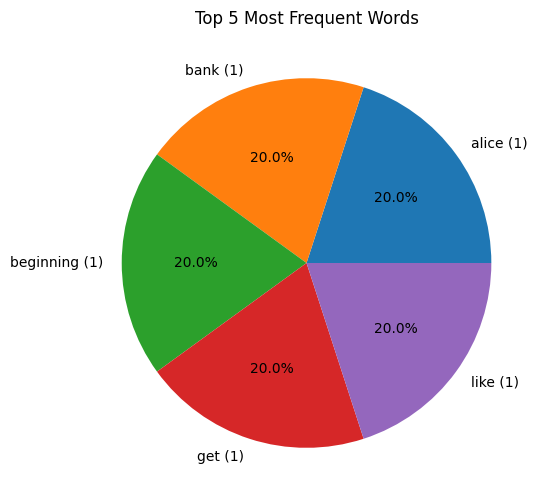

In [179]:
# 4. Display a pie plot of the 5 most frequent words in the text. Add the word and its frequence as labels

import matplotlib.pyplot as plt

# берём слова и их частоты
labels = top_5_words["word"]
sizes = top_5_words["frequency"]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=[f"{word} ({count})" for word, count in zip(labels, sizes)],
    autopct='%1.1f%%'
)

plt.title("Top 5 Most Frequent Words")
plt.show()

A pie chart was created to visualize the distribution of the five most frequent words.
Each segment represents a word and the label shows both the word and its frequency.

**5. Analyse the outputs: Are those words informative? Are they insightful or expected?**

The five most frequent words are partly informative because they show the main repeated topics, characters, or objects in the books.

However, they are also quite expected. In literary texts, the most frequent words are often character names, common actions, or repeated nouns. This means they can help us understand what appears often, but they do not always explain the deeper meaning of the text.

If raw text was used, the results would not be very informative because words like “the”, “and”, “of” would dominate. After preprocessing, the words become more meaningful.

**Solving the frequency problem using TF-IDF:**

In [180]:
# 1. Create another BoW, now using TF-IDF as vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

texts = cleaned_reviews

vectorizer = TfidfVectorizer(min_df=1, max_df=2)

tfidf_matrix = vectorizer.fit_transform(texts)

words = vectorizer.get_feature_names_out()

print("TF-IDF matrix:")
print(tfidf_matrix.toarray())

TF-IDF matrix:
[[0.2773501 0.2773501 0.2773501 0.2773501 0.2773501 0.2773501 0.2773501
  0.2773501 0.2773501 0.2773501 0.2773501 0.2773501 0.2773501]]


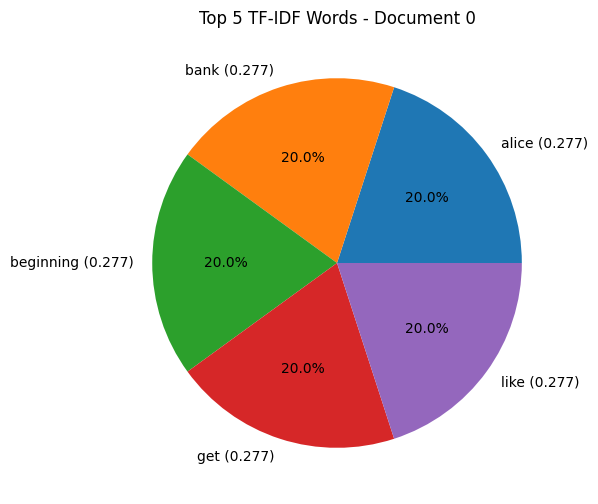

In [181]:
# 2. Create again the pie plots with the new 5 most relevant words from each document

import matplotlib.pyplot as plt

for i, row in enumerate(tfidf_matrix.toarray()):
    df = pd.DataFrame({
        "word": words,
        "score": row
    })

    top_5 = df.sort_values(by="score", ascending=False).head(5)

    labels = top_5["word"]
    sizes = top_5["score"]

    plt.figure(figsize=(6,6))

    plt.pie(
        sizes,
        labels=[f"{w} ({round(s,3)})" for w, s in zip(labels, sizes)],
        autopct='%1.1f%%'
    )

    plt.title(f"Top 5 TF-IDF Words - Document {i}")
    plt.show()